# Merge YOLO Datasets

Ce notebook fusionne le dataset TACO converti en YOLO avec un dataset YOLO existant issu de `train_yolo.ipynb`.

L'objectif est de produire un dataset unique `merged_yolo_dataset` avec un `data.yaml` global.

In [1]:
from pathlib import Path
import shutil
import json
from collections import Counter

import pandas as pd
import yaml

# Helper modules for notebook display
from IPython.display import display

## Inspect Existing YOLO Datasets

Nous allons vérifier la structure des deux datasets à fusionner et définir les chemins attendus.

In [2]:
# Configure these paths before running
source_a_root = Path('dataset/taco_yolo_dataset')
source_b_yaml = Path('dataset/dataset_clean_v1/data_clean.yaml')
# Use the cleaned/fused dataset YAML produced by train_yolo.ipynb

merged_root = Path('dataset/merged_yolo_dataset')

print('Source A root exists:', source_a_root.exists())
print('Source B YAML exists:', source_b_yaml.exists())
print('Merged root will be:', merged_root)

for p in [source_a_root, source_b_yaml.parent, merged_root]:
    print('-', p, 'exists' if p.exists() else 'missing')

Source A root exists: True
Source B YAML exists: True
Merged root will be: dataset\merged_yolo_dataset
- dataset\taco_yolo_dataset exists
- dataset\dataset_clean_v1 exists
- dataset\merged_yolo_dataset exists


## Load Class Names and Dataset Manifests

Cette cellule lit les fichiers `data.yaml` des deux datasets et construit un aperçu des labels et des splits.

In [3]:
def read_data_yaml(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as f:
        return yaml.safe_load(f)


def resolve_split_value(data_yaml: dict, split_name: str) -> str:
    if split_name == 'val':
        return data_yaml.get('val', data_yaml.get('valid', 'val'))
    if split_name == 'valid':
        return data_yaml.get('valid', data_yaml.get('val', 'valid'))
    return data_yaml.get(split_name, split_name)


def get_split_dirs(root: Path, split_value: str) -> tuple[Path | None, Path | None]:
    split_path = root / split_value
    if not split_path.exists():
        return None, None

    if split_path.name == 'images':
        images_dir = split_path
        labels_dir = split_path.parent / 'labels'
    elif split_path.name == 'labels':
        labels_dir = split_path
        images_dir = split_path.parent / 'images'
    else:
        images_dir = split_path / 'images'
        labels_dir = split_path / 'labels'

    return images_dir if images_dir.exists() else None, labels_dir if labels_dir.exists() else None


def dataset_manifest(root: Path, data_yaml: dict) -> dict:
    manifest = {
        'root': root,
        'data_yaml': data_yaml,
        'names': data_yaml['names'],
        'nc': data_yaml['nc'],
        'splits': {},
    }

    for split_name in ['train', 'val', 'test']:
        split_value = resolve_split_value(data_yaml, split_name)
        images_dir, labels_dir = get_split_dirs(root, split_value)
        if images_dir is None and labels_dir is None:
            continue

        manifest['splits'][split_name] = {
            'images': sorted(images_dir.glob('*.*')) if images_dir is not None else [],
            'labels': sorted(labels_dir.glob('*.txt')) if labels_dir is not None else [],
        }

    return manifest


def print_manifest(name: str, manifest: dict):
    print(f"Dataset: {name}")
    print('  root:', manifest['root'])
    print('  classes:', manifest['nc'])
    print('  names count:', len(manifest['names']))
    print('  class names:')
    for i, class_name in enumerate(manifest['names']):
        print(f"    {i}: {class_name}")
    print('  splits:')
    for split, paths in manifest['splits'].items():
        print(f"    - {split}: {len(paths['images'])} images, {len(paths['labels'])} labels")
    print()  


# Load sources
source_a_yaml = source_a_root / 'data.yaml'
source_b_root = source_b_yaml.parent

source_a_cfg = read_data_yaml(source_a_yaml)
source_b_cfg = read_data_yaml(source_b_yaml)

source_a_manifest = dataset_manifest(source_a_root, source_a_cfg)
source_b_manifest = dataset_manifest(source_b_root, source_b_cfg)

print_manifest('TACO YOLO', source_a_manifest)
print_manifest('Existing YOLO', source_b_manifest)


Dataset: TACO YOLO
  root: dataset\taco_yolo_dataset
  classes: 26
  names count: 26
  class names:
    0: Tin
    1: Bottle
    2: Bottle glass
    3: Plastic bottle cap
    4: Metal
    5: Food Can
    6: Aerosol
    7: Cardboard
    8: Paper cup
    9: Plastic cup
    10: Foam cup
    11: Organic
    12: Plastic
    13: Paper
    14: Tissues
    15: Wrapping paper
    16: Paper bag
    17: Plastified paper bag
    18: Plastic film
    19: Garbage bag
    20: Food Packet
    21: Disposable food container
    22: Foam food container
    23: Plastic utensils
    24: Scrap metal
    25: Styrofoam piece
  splits:
    - train: 1200 images, 1200 labels
    - val: 150 images, 150 labels
    - test: 150 images, 150 labels

Dataset: Existing YOLO
  root: dataset\dataset_clean_v1
  classes: 27
  names count: 27
  class names:
    0: Aerosols
    1: Tin
    2: Cardboard
    3: Cellulose
    4: Ceramic
    5: Combined plastic
    6: Container for household chemicals
    7: Disposable tableware
 

## Align Category IDs Between Datasets

Nous construisons une liste unifiée de classes et un mapping d'IDs pour chaque dataset.

Si certaines classes doivent être fusionnées manuellement, il est possible de compléter `manual_name_map`.

In [ ]:
def normalize_name(name: str) -> str:
    return name.strip().lower()

# Manual mapping for semantic class alignment between datasets.
manual_name_map = {
    'Aerosol': 'Metal',
    'Aerosols': 'Metal',
    'Bottle glass': 'Glass bottle',
    'Plastic film': 'Stretch film',
    'Bottle': 'Plastic bottle',
    'Food can': 'Metal',
    'Scrap metal': 'Metal',
    'Container for household chemicals': 'Plastic bottle',
    'Garbage bag': 'Soft plastic',
    'Stretch film': 'Soft plastic',
    'Plastic bag': 'Soft plastic',
    'Tin' : 'Metal',
    'Plastic cup': 'Cup',
    'Paper cup': 'Cup',
    'Foam cup': 'Cup',
}

all_names = []
name_to_unified = {}

for dataset_name, names in [('A', source_a_manifest['names']), ('B', source_b_manifest['names'])]:
    for cls in names:
        normalized = manual_name_map.get(cls, cls).strip()
        if normalized not in name_to_unified:
            name_to_unified[normalized] = len(name_to_unified)
            all_names.append(normalized)

print('Unified class count:', len(all_names))
print()

# Create mapping tables for each dataset
source_a_id_map = {i: name_to_unified[manual_name_map.get(name, name).strip()] for i, name in enumerate(source_a_manifest['names'])}
source_b_id_map = {i: name_to_unified[manual_name_map.get(name, name).strip()] for i, name in enumerate(source_b_manifest['names'])}

print('Sample mappings from source A:')
for i in range(min(10, len(source_a_manifest['names']))):
    print(f'  {i} -> {source_a_manifest["names"][i]!r} -> {source_a_id_map[i]}')

print('\nSample mappings from source B:')
for i in range(min(10, len(source_b_manifest['names']))):
    print(f'  {i} -> {source_b_manifest["names"][i]!r} -> {source_b_id_map[i]}')

Unified class count: 34

Sample mappings from source A:
  0 -> 'Tin' -> 0
  1 -> 'Bottle' -> 1
  2 -> 'Bottle glass' -> 2
  3 -> 'Plastic bottle cap' -> 3
  4 -> 'Metal' -> 0
  5 -> 'Food Can' -> 4
  6 -> 'Aerosol' -> 0
  7 -> 'Cardboard' -> 5
  8 -> 'Paper cup' -> 6
  9 -> 'Plastic cup' -> 6

Sample mappings from source B:
  0 -> 'Aerosols' -> 0
  1 -> 'Tin' -> 0
  2 -> 'Cardboard' -> 5
  3 -> 'Cellulose' -> 21
  4 -> 'Ceramic' -> 22
  5 -> 'Combined plastic' -> 23
  6 -> 'Container for household chemicals' -> 1
  7 -> 'Disposable tableware' -> 24
  8 -> 'Electronics' -> 25
  9 -> 'Foil' -> 26


## Copy Images and Labels into a Merged Dataset

Cette cellule crée le dataset fusionné en copiant les fichiers et en réécrivant les labels avec les nouveaux IDs unifiés.

In [5]:
def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def get_split_dirs(root: Path, split_value: str) -> tuple[Path, Path] | tuple[None, None]:
    split_path = root / split_value
    if not split_path.exists():
        return None, None

    if split_path.name == 'images':
        images_dir = split_path
        labels_dir = split_path.parent / 'labels'
    elif split_path.name == 'labels':
        labels_dir = split_path
        images_dir = split_path.parent / 'images'
    else:
        images_dir = split_path / 'images'
        labels_dir = split_path / 'labels'

    return images_dir if images_dir.exists() else None, labels_dir if labels_dir.exists() else None


def resolve_split_value(data_yaml: dict, split_name: str) -> str:
    if split_name == 'val':
        return data_yaml.get('val', data_yaml.get('valid', 'val'))
    if split_name == 'valid':
        return data_yaml.get('valid', data_yaml.get('val', 'valid'))
    return data_yaml.get(split_name, split_name)


def remap_label_file(src_label: Path, dst_label: Path, id_map: dict[int, int]) -> None:
    lines = []
    for line in src_label.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        parts = line.split()
        try:
            old_id = int(float(parts[0]))
        except ValueError:
            continue
        new_id = id_map.get(old_id)
        if new_id is None:
            continue
        lines.append(' '.join([str(new_id)] + parts[1:]))
    dst_label.write_text('\n'.join(lines) + ('\n' if lines else ''), encoding='utf-8')


def copy_dataset_split(source_root: Path, split: str, yaml_root: dict, id_map: dict[int, int], target_root: Path, target_split: str, prefix: str):
    split_name = resolve_split_value(yaml_root, split)
    images_dir, labels_dir = get_split_dirs(source_root, split_name)
    if images_dir is None:
        return 0, 0

    dst_base = target_root / target_split
    ensure_dir(dst_base / 'images')
    ensure_dir(dst_base / 'labels')

    count = 0
    skipped = 0
    for img_path in sorted(images_dir.glob('*.*')):
        rel_name = img_path.name
        dst_image = dst_base / 'images' / f"{prefix}_{rel_name}"
        if not dst_image.exists():
            shutil.copy2(img_path, dst_image)

        label_name = img_path.with_suffix('.txt').name
        src_label = labels_dir / label_name if labels_dir is not None else source_root / split_name / 'labels' / label_name
        dst_label = dst_base / 'labels' / dst_image.with_suffix('.txt').name
        if src_label.exists():
            remap_label_file(src_label, dst_label, id_map)
            count += 1
        else:
            skipped += 1

    return count, skipped


def merge_datasets(merged_root: Path, datasets: list[tuple[str, Path, dict]], splits: list[str]):
    merged_root.mkdir(parents=True, exist_ok=True)
    stats = []

    canonical_target = {
        'valid': 'val',
        'val': 'val',
        'train': 'train',
        'test': 'test',
    }

    for name, source_root, cfg in datasets:
        print(f'Merging dataset {name}...')
        for split in splits:
            target_split = canonical_target.get(split, split)
            copied, skipped = copy_dataset_split(source_root, split, cfg, cfg['id_map'], merged_root, target_split, name)
            stats.append((name, split, target_split, copied, skipped))
            print(f'  {split} -> {target_split}: copied={copied}, skipped={skipped}')

    return stats


# Prepare datasets for merge
source_a_cfg['id_map'] = source_a_id_map
source_b_cfg['id_map'] = source_b_id_map
merge_datasets_list = [
    ('taco', source_a_root, source_a_cfg),
    ('existing', source_b_root, source_b_cfg),
]

merge_stats = merge_datasets(merged_root, merge_datasets_list, ['train', 'val', 'test'])
print('\nMerge stats:')
for row in merge_stats:
    print(row)


Merging dataset taco...
  train -> train: copied=1200, skipped=0
  val -> val: copied=150, skipped=0
  test -> test: copied=150, skipped=0
Merging dataset existing...
  train -> train: copied=19029, skipped=0
  val -> val: copied=2013, skipped=0
  test -> test: copied=962, skipped=0

Merge stats:
('taco', 'train', 'train', 1200, 0)
('taco', 'val', 'val', 150, 0)
('taco', 'test', 'test', 150, 0)
('existing', 'train', 'train', 19029, 0)
('existing', 'val', 'val', 2013, 0)
('existing', 'test', 'test', 962, 0)


## Generate Unified data.yaml

Le dataset fusionné doit avoir un `data.yaml` avec le chemin racine et la liste des classes unifiées.

In [6]:
merged_yaml = {
    'path': str(merged_root.resolve()),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': len(all_names),
    'names': all_names,
}

data_yaml_path = merged_root / 'data.yaml'
with data_yaml_path.open('w', encoding='utf-8') as f:
    yaml.dump(merged_yaml, f, default_flow_style=False, sort_keys=False)

print(f'Unified data.yaml written to: {data_yaml_path}')
print(f'  classes: {merged_yaml["nc"]}')
print(f'  names sample: {all_names[:20]}')

Unified data.yaml written to: dataset\merged_yolo_dataset\data.yaml
  classes: 34
  names sample: ['Metal', 'Plastic bottle', 'Glass bottle', 'Plastic bottle cap', 'Food Can', 'Cardboard', 'Cup', 'Organic', 'Plastic', 'Paper', 'Tissues', 'Wrapping paper', 'Paper bag', 'Plastified paper bag', 'Stretch film', 'Soft plastic', 'Food Packet', 'Disposable food container', 'Foam food container', 'Plastic utensils']


## Validate the Merged Dataset Structure

Vérifions que le dataset fusionné contient bien des images et des labels pour chaque split attendu.

In [7]:
def count_files(path: Path, ext: str) -> int:
    return len(list(path.glob(f'*{ext}')))

for split in ['train', 'val', 'test']:
    split_dir = merged_root / split
    image_dir = split_dir / 'images'
    label_dir = split_dir / 'labels'
    print(f"Split: {split}")
    print(f"  images: {count_files(image_dir, '.*') if image_dir.exists() else 0}")
    print(f"  labels: {count_files(label_dir, '.txt') if label_dir.exists() else 0}")
    if image_dir.exists() and label_dir.exists():
        print('  sample image:', next(image_dir.glob('*.*'), 'none'))
        print('  sample label:', next(label_dir.glob('*.txt'), 'none'))
    print()

Split: train
  images: 20229
  labels: 20229
  sample image: dataset\merged_yolo_dataset\train\images\existing_00014a42-R_39_jpg.rf.52bac452261f0123684c3d81b496a8ce.jpg
  sample label: dataset\merged_yolo_dataset\train\labels\existing_00014a42-R_39_jpg.rf.52bac452261f0123684c3d81b496a8ce.txt

Split: val
  images: 2163
  labels: 2163
  sample image: dataset\merged_yolo_dataset\val\images\existing_005f0645-R_3968_jpg.rf.10d1634e236449e74facf264ea99241b.jpg
  sample label: dataset\merged_yolo_dataset\val\labels\existing_005f0645-R_3968_jpg.rf.10d1634e236449e74facf264ea99241b.txt

Split: test
  images: 1112
  labels: 1112
  sample image: dataset\merged_yolo_dataset\test\images\existing_00a6aeda-R_2700_jpg.rf.1797deb3cd3719c057a81a3442df4f26.jpg
  sample label: dataset\merged_yolo_dataset\test\labels\existing_00a6aeda-R_2700_jpg.rf.1797deb3cd3719c057a81a3442df4f26.txt



## Vérification des classes du nouveau dataset 

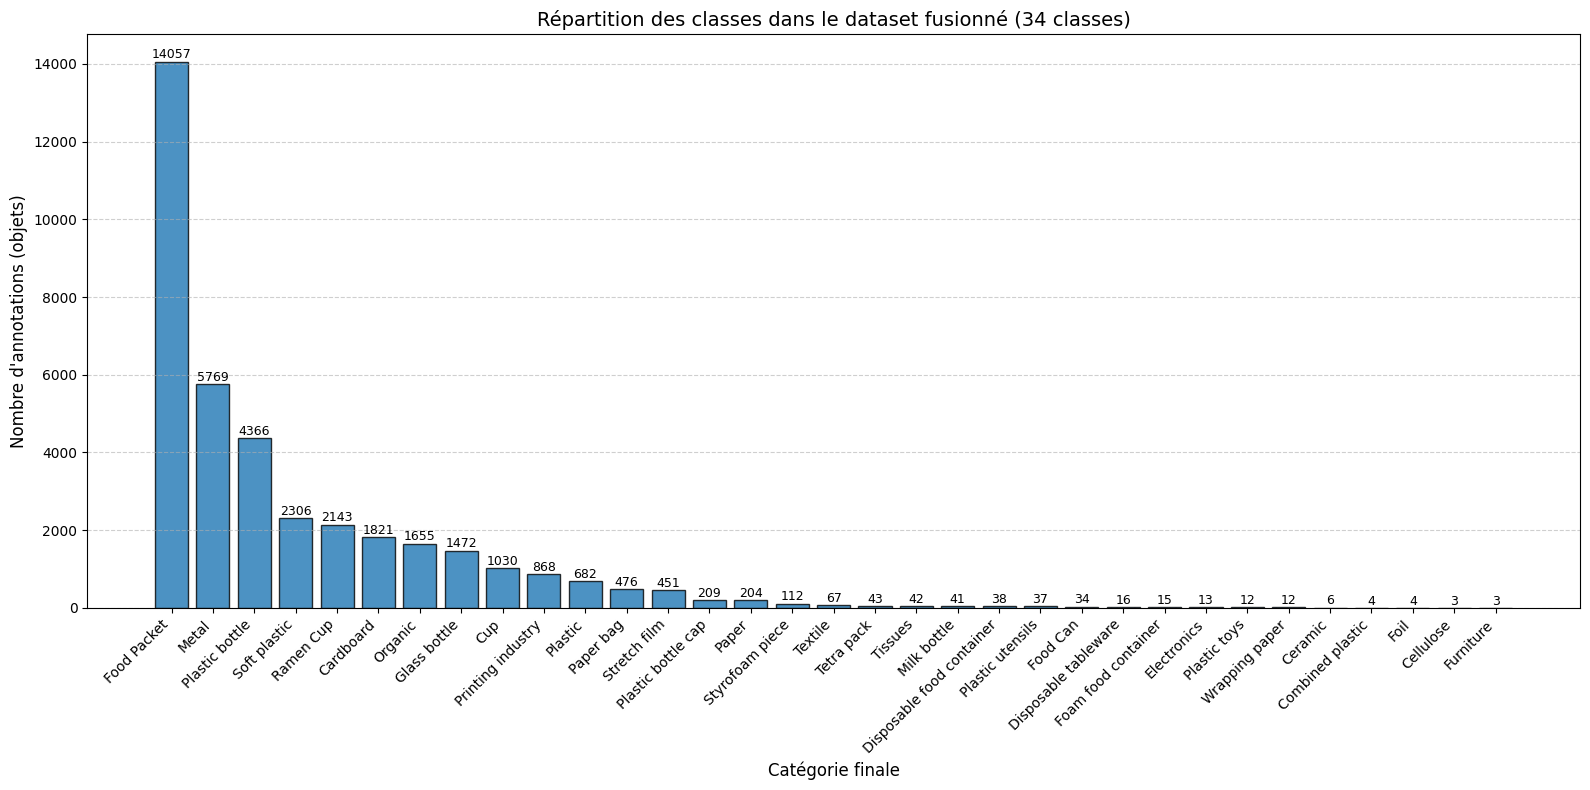

Nombre total de classes unifiées : 34
Nombre total d'objets annotés : 38011


In [8]:
import matplotlib.pyplot as plt

# 1. Compter les occurrences de chaque classe dans le dataset fusionné
final_counts = Counter()

# On parcourt tous les labels de tous les splits (train, val, test)
for split in ['train', 'val', 'test']:
    label_dir = merged_root / split / 'labels'
    if label_dir.exists():
        for label_file in label_dir.glob('*.txt'):
            with label_file.open('r') as f:
                for line in f:
                    parts = line.split()
                    if parts:
                        class_id = int(parts[0])
                        final_counts[class_id] += 1

# 2. Préparer les données pour le graphique
# On récupère le nom de la classe associé à l'ID
plot_data = []
for class_id, count in final_counts.items():
    class_name = all_names[class_id]
    plot_data.append((class_name, count))

# Trier par nombre d'annotations décroissant
plot_data.sort(key=lambda x: x[1], reverse=True)

names = [x[0] for x in plot_data]
counts = [x[1] for x in plot_data]

# 3. Création du graphique
plt.figure(figsize=(16, 8))
bars = plt.bar(names, counts, color='#1f77b4', edgecolor='black', alpha=0.8)

# Configuration esthétique
plt.title(f'Répartition des classes dans le dataset fusionné ({len(all_names)} classes)', fontsize=14)
plt.xlabel('Catégorie finale', fontsize=12)
plt.ylabel('Nombre d\'annotations (objets)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Ajouter les chiffres au-dessus des barres pour plus de précision
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Affichage du résumé textuel
print(f"Nombre total de classes unifiées : {len(all_names)}")
print(f"Nombre total d'objets annotés : {sum(counts)}")